In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('C:\\Users\\sansu\\Downloads\\DTSC 2301\\dataset\\pokemon.csv')

In [43]:
df.head()

,number,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,Mega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,3,Gigantamax Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072 entries, 0 to 1071
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   number      1072 non-null   int64 
 1   name        1072 non-null   object
 2   type1       1072 non-null   object
 3   type2       574 non-null    object
 4   total       1072 non-null   int64 
 5   hp          1072 non-null   int64 
 6   attack      1072 non-null   int64 
 7   defense     1072 non-null   int64 
 8   sp_attack   1072 non-null   int64 
 9   sp_defense  1072 non-null   int64 
 10  speed       1072 non-null   int64 
 11  generation  1072 non-null   int64 
 12  legendary   1072 non-null   bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 101.7+ KB


In [45]:
#looking for null values

null_mask = df.isnull()
rows_with_nulls = null_mask.any(axis=1)
null_counts = df.isnull().sum()
row_null_counts = df.isnull().sum(axis=1)
print(row_null_counts)

0       0
1       0
2       0
3       0
4       0
       ..
1067    1
1068    1
1069    0
1070    0
1071    0
Length: 1072, dtype: int64


In [46]:
df['legendary'].dtype
df['legendary'].unique()

array([False,  True])

In [ ]:
#finding to see why blastoise is a seperate category and why grass is misspelled as graass
print(df['type1'].unique())

# Finding rows where type1 is "Blastoise" or "Grass"
print(df[df['type1'] == 'Blastoise'])
print(df[df['type1'] == 'Grass'])

['Grass' 'Fire' 'Water' 'Blastoise' 'Bug' 'Normal' 'Dark' 'Poison'
 'Electric' 'Ground' 'Ice' 'Fairy' 'Steel' 'Fighting' 'Psychic' 'Rock'
 'Ghost' 'Dragon' 'Flying' 'Graass']
    number                 name      type1  type2  total  hp  attack  defense  \
15       9  Gigantamax Blasoise  Blastoise  Water    530  79      83      100   

    sp_attack  sp_defense  speed  generation  legendary  
15         85         105     78           1      False  
     number                 name  type1   type2  total   hp  attack  defense  \
0         1            Bulbasaur  Grass  Poison    318   45      49       49   
1         2              Ivysaur  Grass  Poison    405   60      62       63   
2         3             Venusaur  Grass  Poison    525   80      82       83   
3         3        Mega Venusaur  Grass  Poison    625   80     100      123   
4         3  Gigantamax Venusaur  Grass  Poison    525   80      82       83   
..      ...                  ...    ...     ...    ...  ...     ..

In [ ]:
# fixing blastoise being its own category and grass being misspelled as graass
df.loc[df['type1'] == 'Blastoise', 'type1'] = 'Water'
df.loc[df['type1'] == 'Graass', 'type1'] = 'Grass'

#veryfiing
print(df['type1'].unique())

# Saved the new version
df.to_csv('C:\\Users\\sansu\\Downloads\\DTSC 2301\\dataset\\pokemon_cleaned.csv', index=False)

['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Dark' 'Poison' 'Electric' 'Ground'
 'Ice' 'Fairy' 'Steel' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Dragon'
 'Flying']


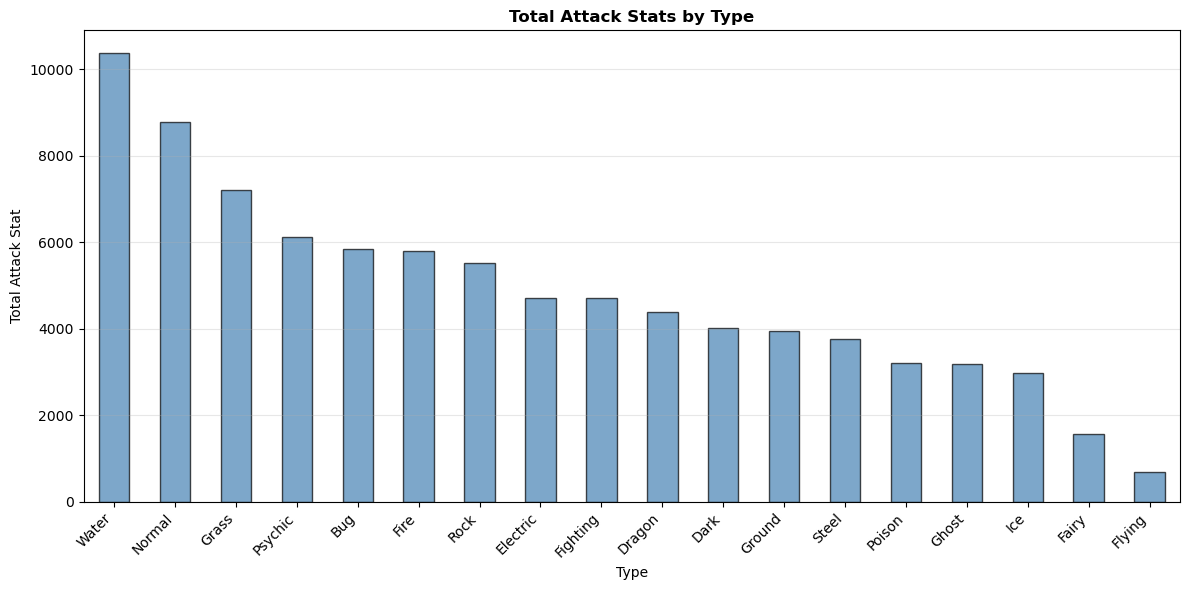

In [49]:
# Sum of attack stats by type
attack_by_type = df.groupby('type1')['attack'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
attack_by_type.plot(kind='bar', edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Total Attack Stats by Type', fontsize=12, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Total Attack Stat')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

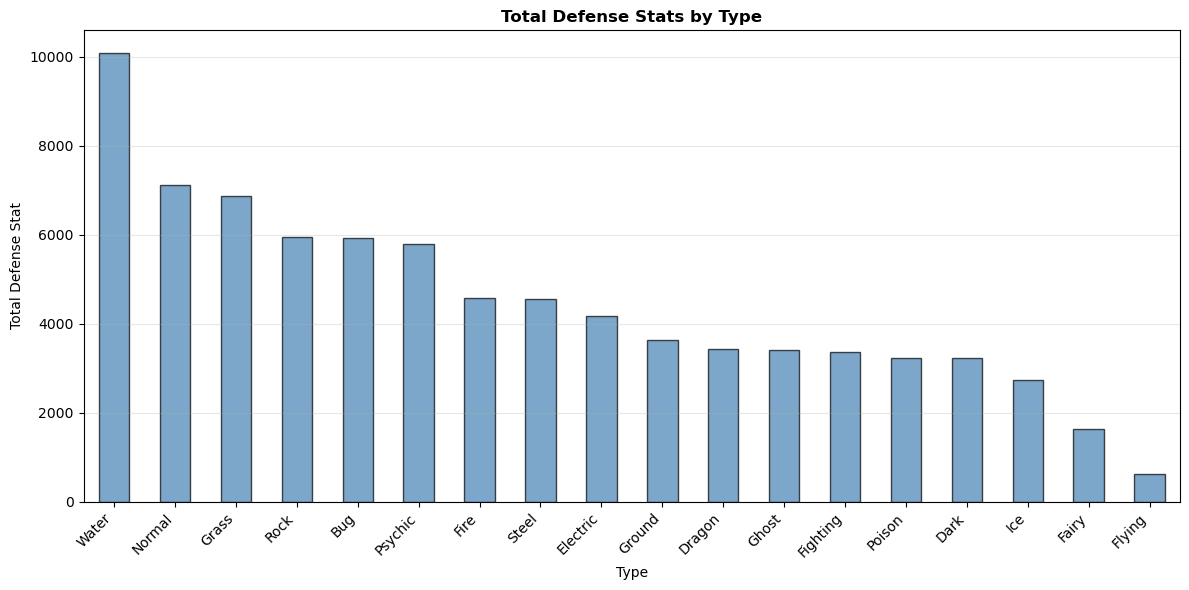

In [50]:
# Sum of defense stats by type
defense_by_type = df.groupby('type1')['defense'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
defense_by_type.plot(kind='bar', edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Total Defense Stats by Type', fontsize=12, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Total Defense Stat')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

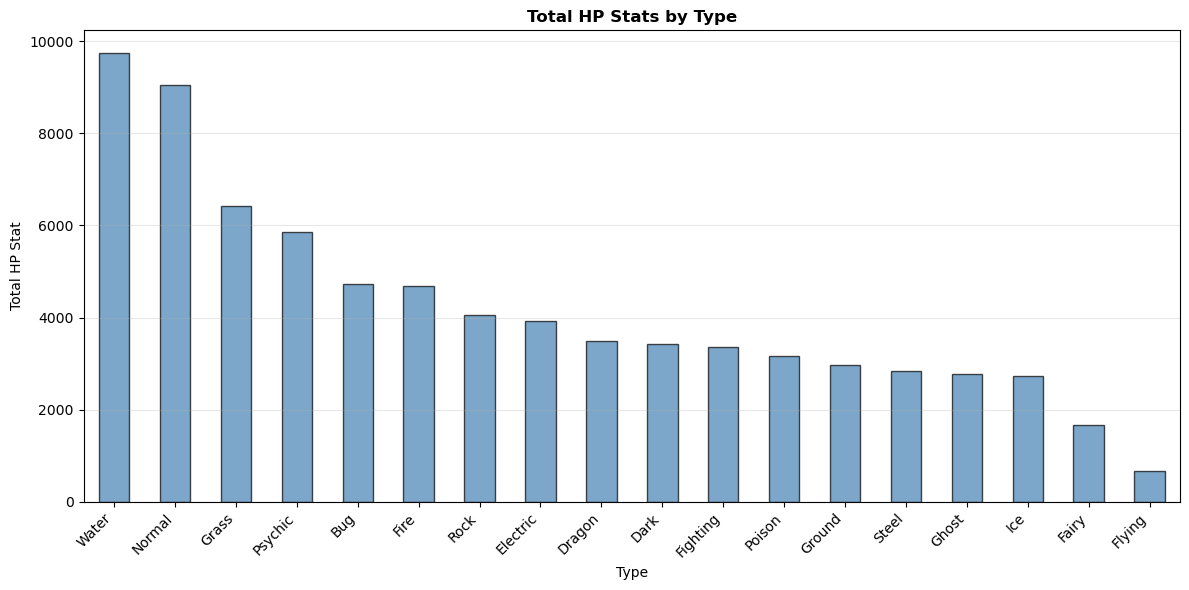

In [51]:
hp_by_type = df.groupby('type1')['hp'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
hp_by_type.plot(kind='bar', edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Total HP Stats by Type', fontsize=12, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Total HP Stat')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

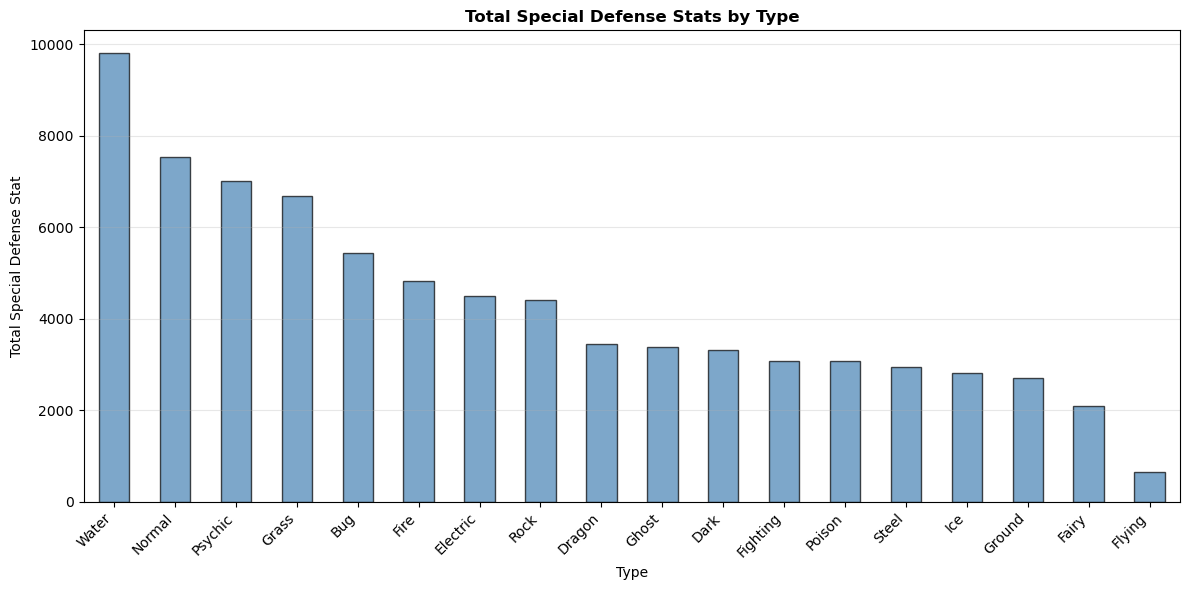

In [52]:
sp_defense_by_type = df.groupby('type1')['sp_defense'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sp_defense_by_type.plot(kind='bar', edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Total Special Defense Stats by Type', fontsize=12, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Total Special Defense Stat')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

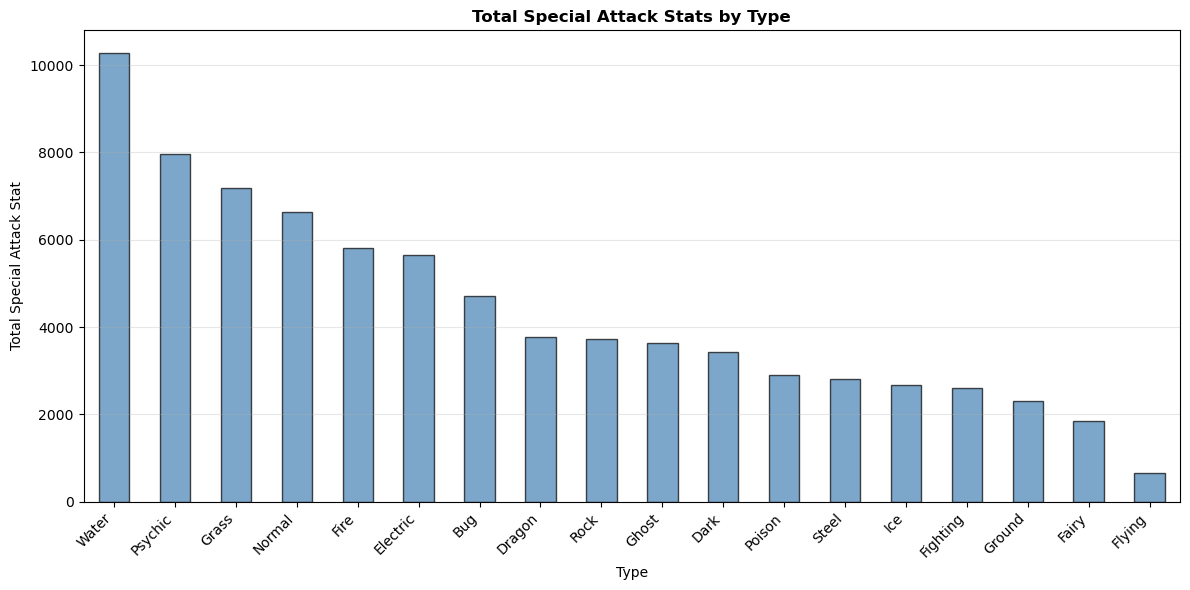

In [53]:
sp_attack_by_type = df.groupby('type1')['sp_attack'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sp_attack_by_type.plot(kind='bar', edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Total Special Attack Stats by Type', fontsize=12, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Total Special Attack Stat')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

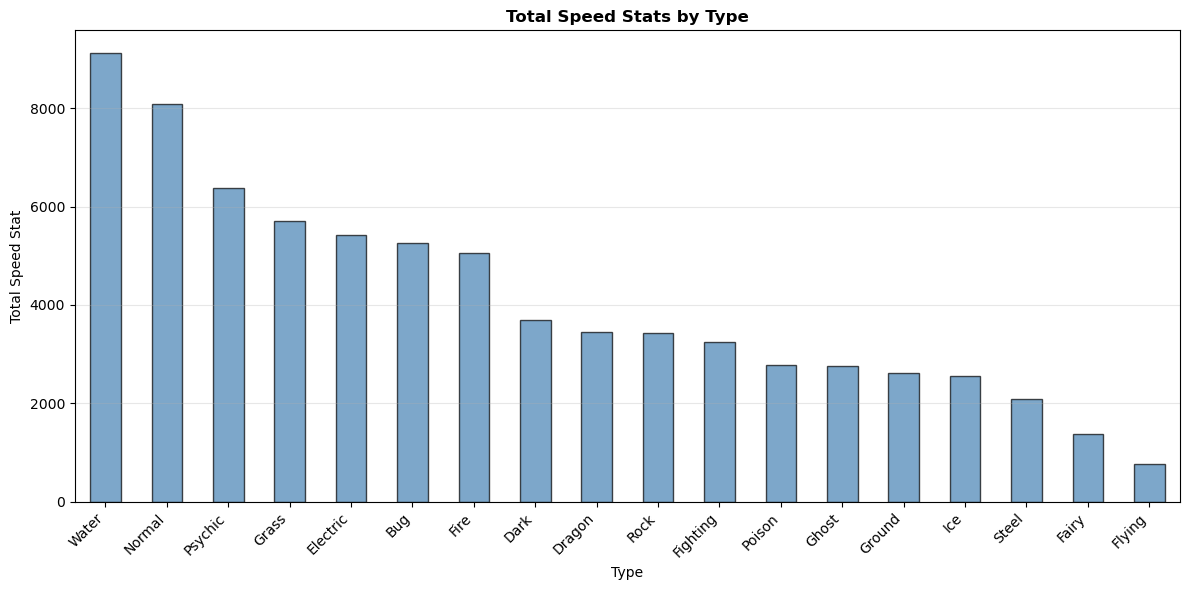

In [54]:
speed_by_type = df.groupby('type1')['speed'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
speed_by_type.plot(kind='bar', edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Total Speed Stats by Type', fontsize=12, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Total Speed Stat')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

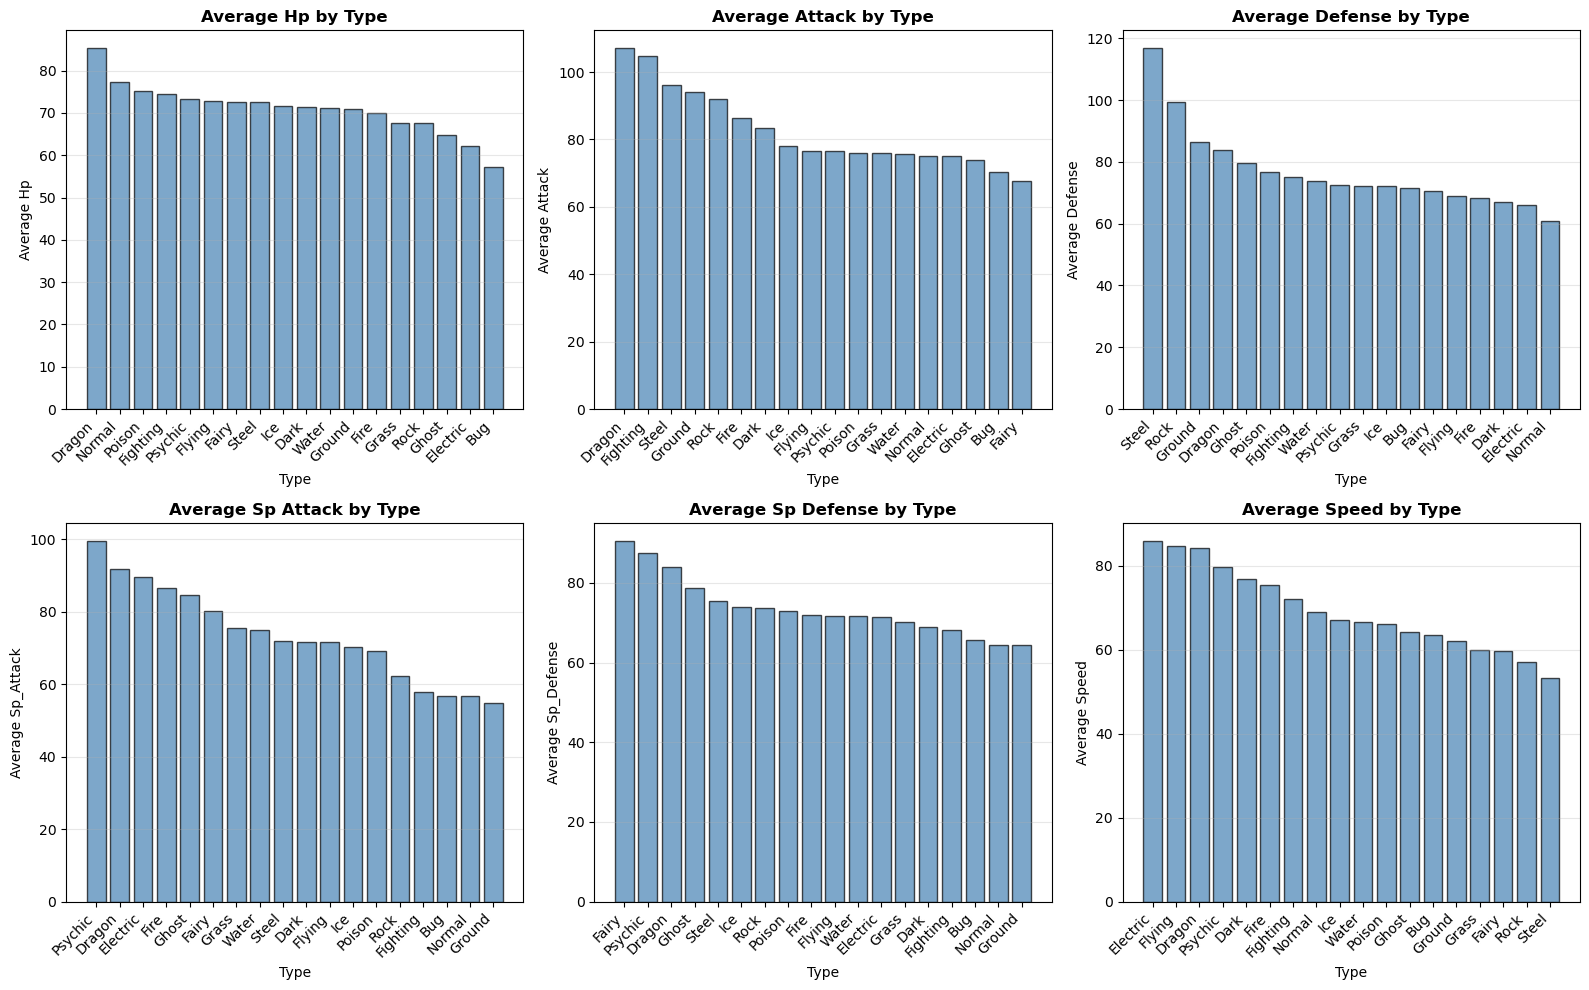

In [55]:
# Average stats for all stat types
stats_to_plot = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, stat in enumerate(stats_to_plot):
    avg_by_type = df.groupby('type1')[stat].mean().sort_values(ascending=False)
    axes[idx].bar(range(len(avg_by_type)), avg_by_type.values, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Average {stat.replace("_", " ").title()} by Type', fontweight='bold')
    axes[idx].set_xlabel('Type')
    axes[idx].set_ylabel(f'Average {stat.title()}')
    axes[idx].set_xticks(range(len(avg_by_type)))
    axes[idx].set_xticklabels(avg_by_type.index, rotation=45, ha='right')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

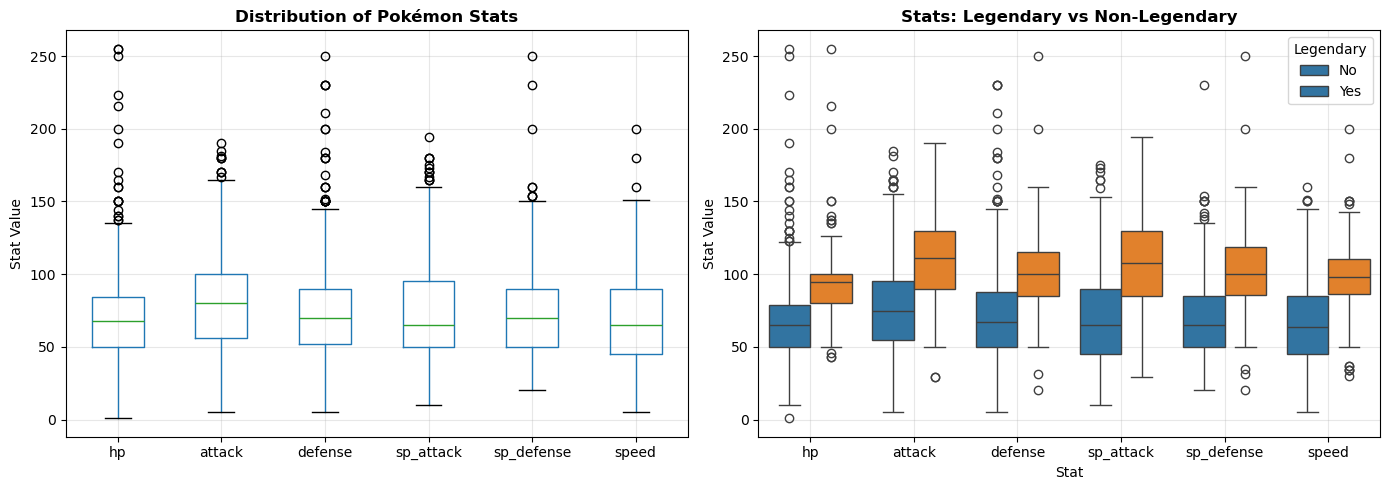

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of stats (boxplot)
stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
df[stats_cols].boxplot(ax=axes[0])
axes[0].set_title('Distribution of Pokémon Stats', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Stat Value')
axes[0].grid(True, alpha=0.3)

# Plot 2: Legendary vs Non-Legendary comparison
# boxplot
df_melted = df.melt(id_vars=['legendary'], 
                     value_vars=stats_cols,
                     var_name='Stat', 
                     value_name='Value')

sns.boxplot(data=df_melted, x='Stat', y='Value', hue='legendary', ax=axes[1])
axes[1].set_title('Stats: Legendary vs Non-Legendary', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Stat Value')
axes[1].legend(title='Legendary', labels=['No', 'Yes'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

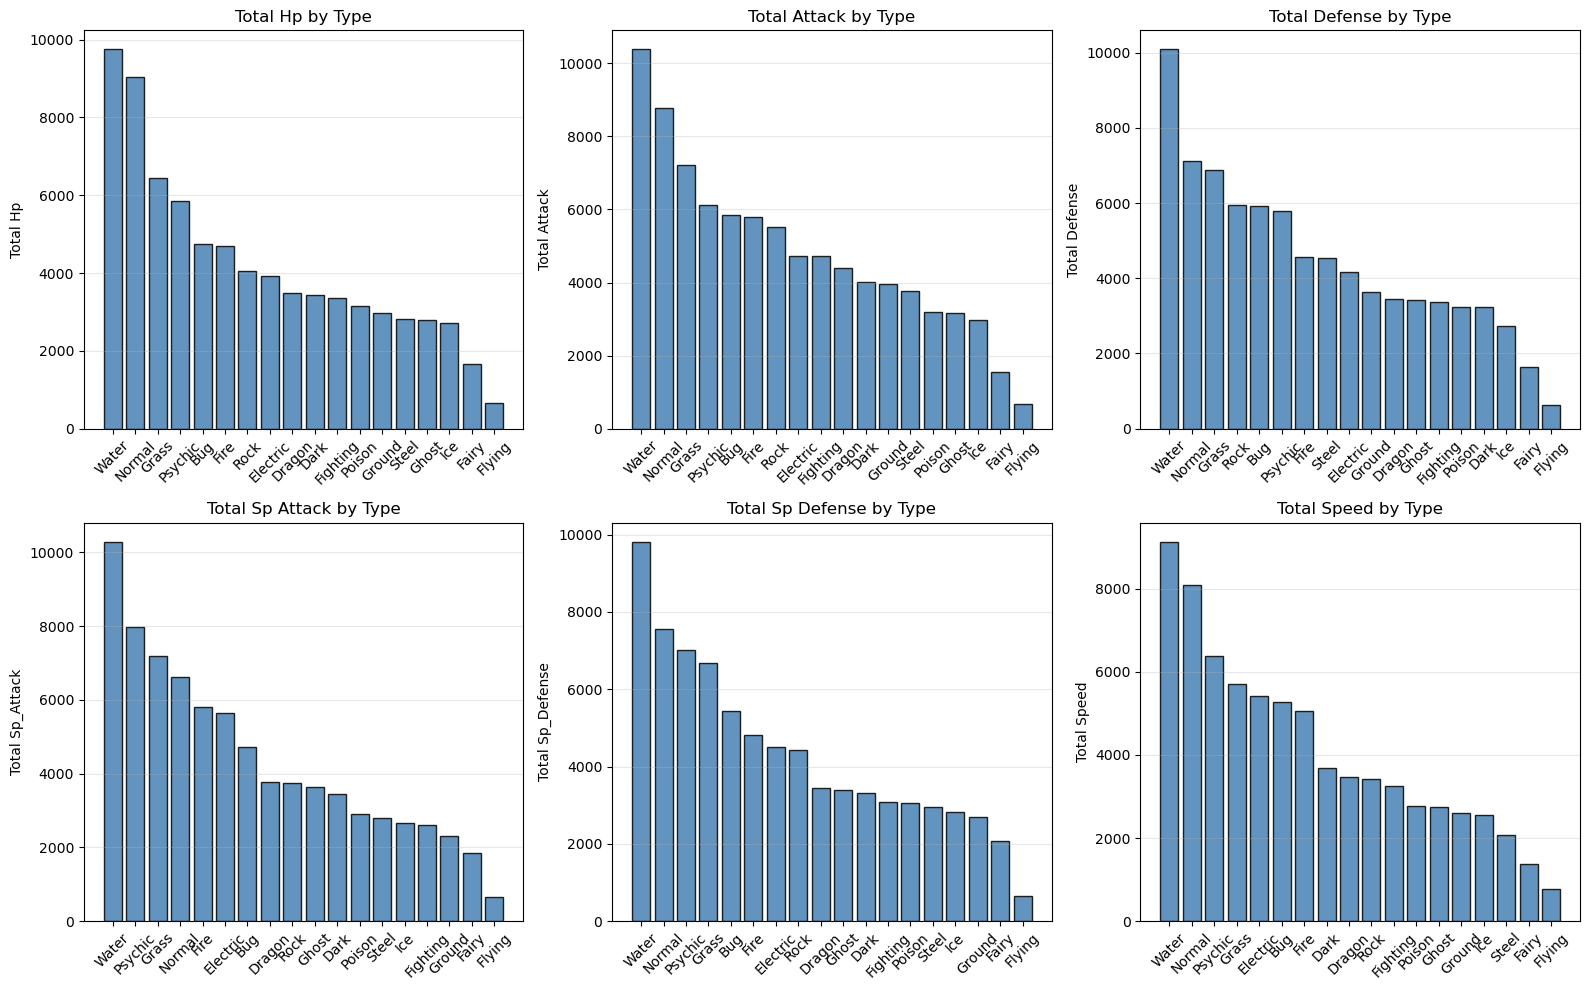

In [ ]:
stats_to_plot = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
totals_by_type = df.groupby('type1')[stats_to_plot].sum()

# 2x3 grid worked best
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, stat in enumerate(stats_to_plot):
    totals = totals_by_type[stat].sort_values(ascending=False)
    axes[i].bar(totals.index, totals.values, color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].set_title(f"Total {stat.replace('_',' ').title()} by Type")
    axes[i].set_ylabel(f"Total {stat.title()}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

